In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns


In [ ]:
df2 = pd.read_csv("IPL_ball_by_ball.csv")
df = pd.read_csv("ipl_team.csv")

/tmp/ipykernel_8485/728555434.py:1: DtypeWarning: Columns (28,29,30,31,43,46,47,48,51) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("IPL_ball_by_ball.csv")


In [20]:
df.head()

,Unnamed: 0,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,...,team_runs,team_balls,team_wicket,new_batter,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
0,131970,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,...,1,1,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
1,131971,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,...,1,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
2,131972,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
3,131973,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,3,0,NaN,0,2,0,"('BB McCullum', 'SC Ganguly')",NaN,False
4,131974,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,...,2,4,0,NaN,0,3,0,"('BB McCullum', 'SC Ganguly')",NaN,False


In [21]:
df.shape

(278205, 64)

In [22]:
df['batting_team'].value_counts()

batting_team
Mumbai Indians                 33323
Kolkata Knight Riders          30895
Chennai Super Kings            30395
Royal Challengers Bangalore    28205
Rajasthan Royals               27922
Sunrisers Hyderabad            23442
Kings XI Punjab                22646
Delhi Daredevils               18786
Delhi Capitals                 12615
Deccan Chargers                 9034
Punjab Kings                    8865
Gujarat Titans                  7331
Lucknow Super Giants            7144
Pune Warriors                   5443
Gujarat Lions                   3566
Royal Challengers Bengaluru     3531
Rising Pune Supergiant          1900
Kochi Tuskers Kerala            1582
Rising Pune Supergiants         1580
Name: count, dtype: int64

In [23]:
print(list(df.columns))


['Unnamed: 0', 'match_id', 'date', 'match_type', 'event_name', 'innings', 'batting_team', 'bowling_team', 'over', 'ball', 'ball_no', 'batter', 'bat_pos', 'runs_batter', 'balls_faced', 'bowler', 'valid_ball', 'runs_extras', 'runs_total', 'runs_bowler', 'runs_not_boundary', 'extra_type', 'non_striker', 'non_striker_pos', 'wicket_kind', 'player_out', 'fielders', 'runs_target', 'review_batter', 'team_reviewed', 'review_decision', 'umpire', 'umpires_call', 'player_of_match', 'match_won_by', 'win_outcome', 'toss_winner', 'toss_decision', 'venue', 'city', 'day', 'month', 'year', 'season', 'gender', 'team_type', 'superover_winner', 'result_type', 'method', 'balls_per_over', 'overs', 'event_match_no', 'stage', 'match_number', 'team_runs', 'team_balls', 'team_wicket', 'new_batter', 'batter_runs', 'batter_balls', 'bowler_wicket', 'batting_partners', 'next_batter', 'striker_out']


In [24]:
# to merge three columns into one column
df['year'] = df['day'].astype(str) + '-' + df['month'].astype(str) + '-' + df['season'].astype(str)

In [25]:
df['year'].head()

0    18-4-2007/08
1    18-4-2007/08
2    18-4-2007/08
3    18-4-2007/08
4    18-4-2007/08
Name: year, dtype: object

In [26]:
df['year'].head()

0    18-4-2007/08
1    18-4-2007/08
2    18-4-2007/08
3    18-4-2007/08
4    18-4-2007/08
Name: year, dtype: object

In [27]:
df['day'].head()
# to see multiple columns
df[['day', 'month', 'year']].head()

,day,month,year
0,18,4,18-4-2007/08
1,18,4,18-4-2007/08
2,18,4,18-4-2007/08
3,18,4,18-4-2007/08
4,18,4,18-4-2007/08


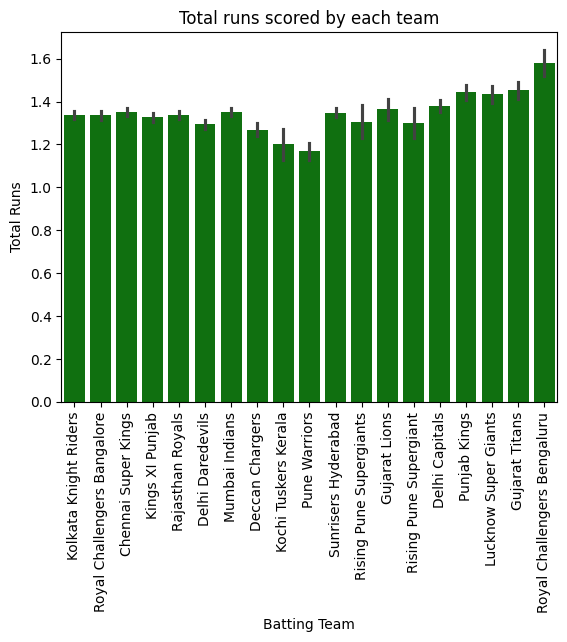

In [28]:
sns.barplot(x=df['batting_team'], y=df['runs_total'], color='green')
plt.title('Total runs scored by each team')
plt.xticks(rotation=90)
plt.xlabel('Batting Team')
plt.ylabel('Total Runs')
plt.show()

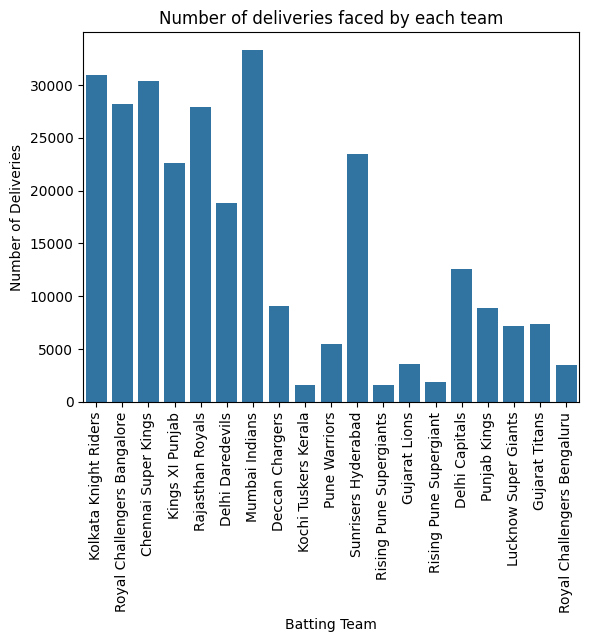

In [29]:
sns.countplot(x=df['batting_team'])
plt.title('Number of deliveries faced by each team')
plt.xticks(rotation=90)
plt.xlabel('Batting Team')
plt.ylabel('Number of Deliveries')
plt.show()
# this will 

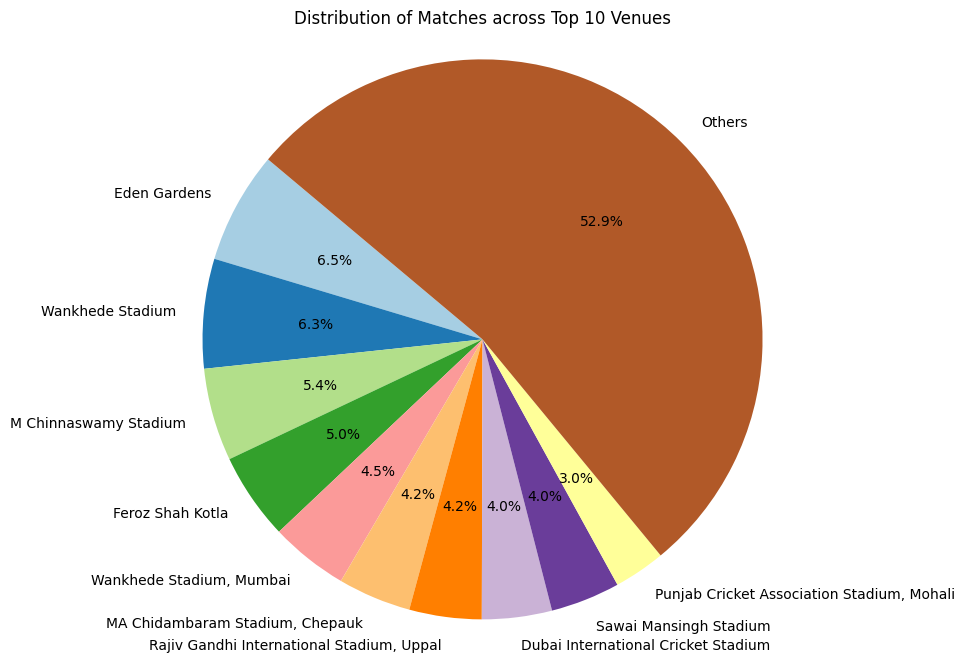

In [30]:

import matplotlib.pyplot as plt   # ensure plt is defined before use
# (already imported in an earlier cell, so this import is harmless)

venue_counts = df['venue'].value_counts()
top_venues = venue_counts.head(10)
others_count = venue_counts.iloc[10:].sum()
top_venues['Others'] = others_count

plt.figure(figsize=(10, 8))
cmap = plt.get_cmap('Paired')
colors = [cmap(i) for i in np.linspace(0, 1, len(top_venues))]

plt.pie(top_venues,
        labels=top_venues.index.tolist(),
        autopct='%1.1f%%',
        startangle=140,
        colors=colors)

plt.title('Distribution of Matches across Top 10 Venues')
plt.axis('equal')
plt.show()

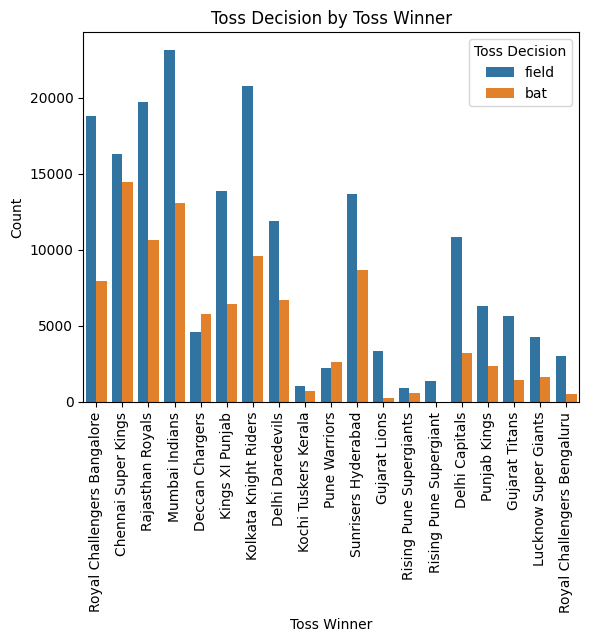

In [31]:
sns.countplot(x=df['toss_winner'],  hue=df['toss_decision'])
plt.title('Toss Decision by Toss Winner')
plt.xticks(rotation=90)
plt.xlabel('Toss Winner')
plt.ylabel('Count')
plt.legend(title='Toss Decision')

plt.show()

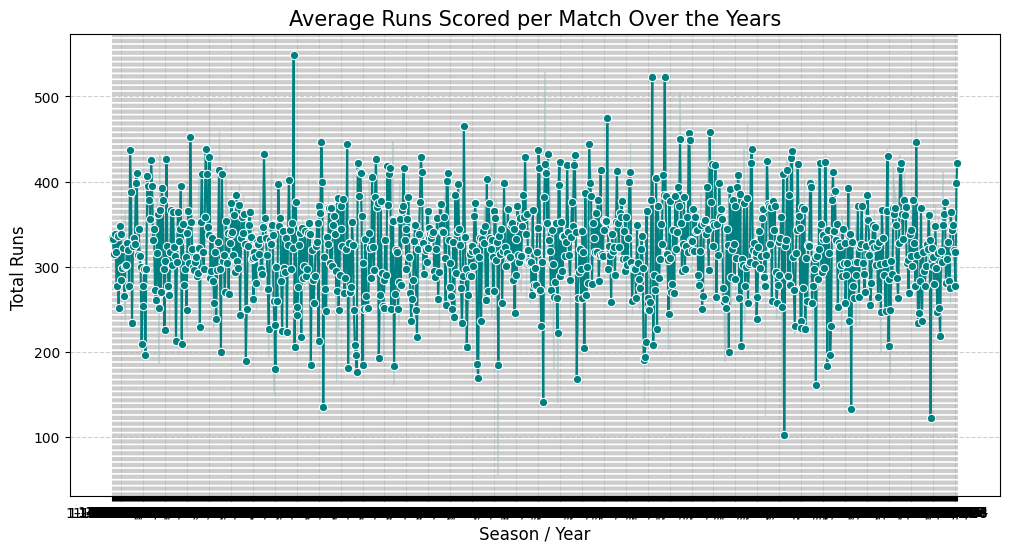

In [32]:
match_runs = df.groupby(['year', 'match_id'])['runs_total'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=match_runs, x='year', y='runs_total', marker='o', color='teal')

plt.title('Average Runs Scored per Match Over the Years', fontsize=15)
plt.xlabel('Season / Year', fontsize=12)
plt.ylabel('Total Runs ', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

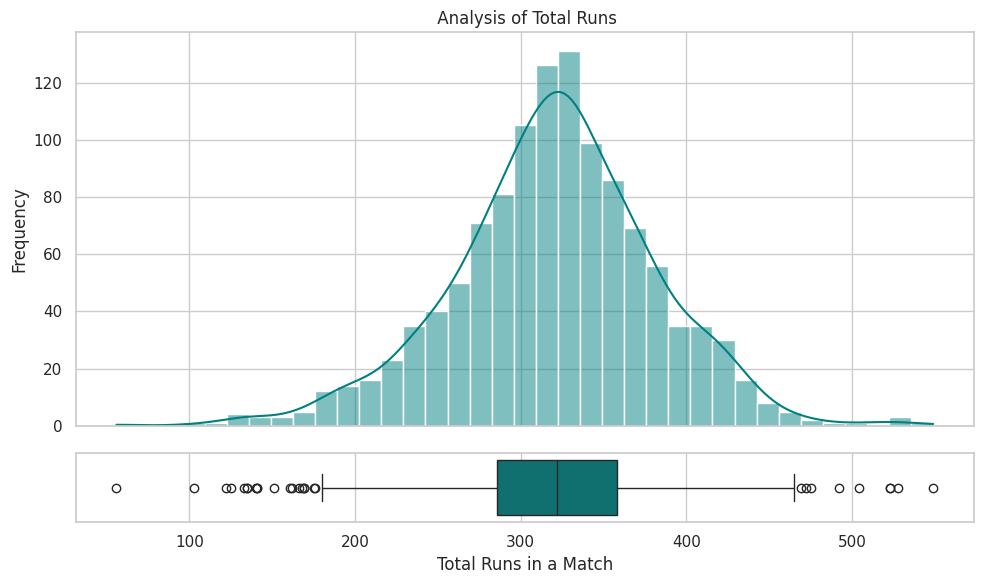

In [33]:
sns.set_theme(style="whitegrid")


fig, (ax_hist, ax_box) = plt.subplots(2, sharex=True, 
                                     gridspec_kw={"height_ratios": (.85, .15)}, 
                                     figsize=(10, 6))

sns.histplot(data=match_runs, x='runs_total', kde=True, color='teal', ax=ax_hist)
ax_hist.set(title=' Analysis of Total Runs', ylabel='Frequency')


sns.boxplot(data=match_runs, x='runs_total', color='teal', ax=ax_box)
ax_box.set(xlabel='Total Runs in a Match')

plt.tight_layout()
plt.show()

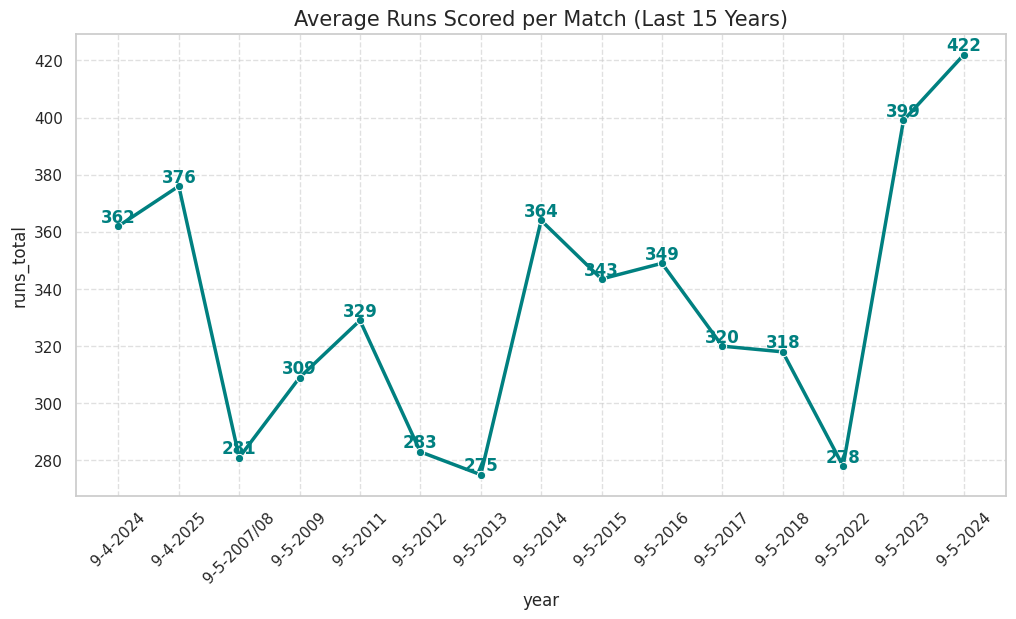

In [34]:
yearly_avg = match_runs.groupby('year')['runs_total'].mean().reset_index()


yearly_avg = yearly_avg.tail(15)

plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_avg, x='year', y='runs_total', marker='o', color='teal', linewidth=2.5)

for x, y in zip(yearly_avg['year'], yearly_avg['runs_total']):
    plt.text(x, y, f'{int(y)}', color='teal', va='bottom', ha='center', fontweight='bold')

plt.title('Average Runs Scored per Match (Last 15 Years)', fontsize=15)
plt.xticks(yearly_avg['year']) 
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [35]:
df1 = pd.read_csv('IPL_ball_by_ball.csv')

/tmp/ipykernel_8485/406009299.py:1: DtypeWarning: Columns (28,29,30,31,43,46,47,48,51) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv('IPL_ball_by_ball.csv')


In [36]:
print(list(df1.columns))

['Unnamed: 0', 'match_id', 'date', 'match_type', 'event_name', 'innings', 'batting_team', 'bowling_team', 'over', 'ball', 'ball_no', 'batter', 'bat_pos', 'runs_batter', 'balls_faced', 'bowler', 'valid_ball', 'runs_extras', 'runs_total', 'runs_bowler', 'runs_not_boundary', 'extra_type', 'non_striker', 'non_striker_pos', 'wicket_kind', 'player_out', 'fielders', 'runs_target', 'review_batter', 'team_reviewed', 'review_decision', 'umpire', 'umpires_call', 'player_of_match', 'match_won_by', 'win_outcome', 'toss_winner', 'toss_decision', 'venue', 'city', 'day', 'month', 'year', 'season', 'gender', 'team_type', 'superover_winner', 'result_type', 'method', 'balls_per_over', 'overs', 'event_match_no', 'stage', 'match_number', 'team_runs', 'team_balls', 'team_wicket', 'new_batter', 'batter_runs', 'batter_balls', 'bowler_wicket', 'batting_partners', 'next_batter', 'striker_out']


In [37]:
df1['runs_total']

0         1
1         0
2         1
3         0
4         0
         ..
278200    0
278201    6
278202    4
278203    6
278204    6
Name: runs_total, Length: 278205, dtype: int64

In [38]:
df1['runs_total']

0         1
1         0
2         1
3         0
4         0
         ..
278200    0
278201    6
278202    4
278203    6
278204    6
Name: runs_total, Length: 278205, dtype: int64

<Axes: ylabel='Count'>

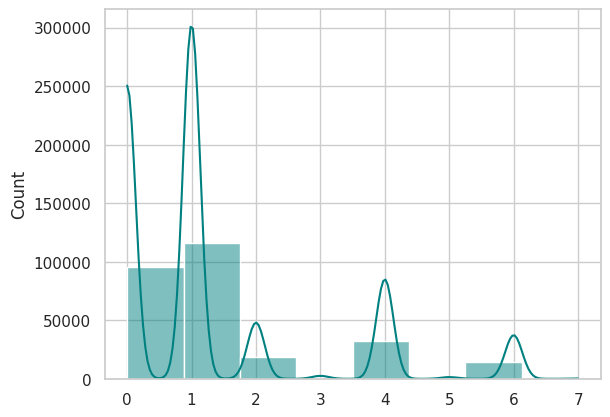

In [39]:
sns.histplot(x=df['runs_total'].values, bins=8, kde=True, color='teal')